# Member 4 - Feature Engineering

**Student ID:** IT25102313
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
Feature engineering using an interaction feature.

## Explanation
Feature engineering creates new variables from existing features to represent
potential patterns or relationships that are not explicitly available in the
original dataset.

## Justification
Age and BMI are two numerical characteristics available in the insurance
dataset.

Their combined effect may contain additional information related to medical
insurance charges.

Therefore, a new interaction feature called `age_bmi_interaction` will be
created:

age_bmi_interaction = age × bmi

The usefulness of the new feature should later be validated through model
performance rather than automatically assumed.

## EDA
A scatter plot will be used to investigate the relationship between the new
interaction feature and insurance charges.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df["age_bmi_interaction"] = (
    df["age"] * df["bmi"]
)

print("New feature created successfully.")

display(
    df[
        [
            "age",
            "bmi",
            "age_bmi_interaction",
            "charges"
        ]
    ].head()
)

New feature created successfully.


,age,bmi,age_bmi_interaction,charges
0,19,27.900,530.100,16884.92400
1,18,33.770,607.860,1725.55230
2,28,33.000,924.000,4449.46200
3,33,22.705,749.265,21984.47061
4,32,28.880,924.160,3866.85520


In [4]:
print("Age-BMI Interaction Summary:")

display(
    df["age_bmi_interaction"].describe()
)

Age-BMI Interaction Summary:


count    1338.000000
mean     1211.575919
std       522.608731
min       287.280000
25%       765.625000
50%      1152.225000
75%      1589.085000
max      2845.480000
Name: age_bmi_interaction, dtype: float64

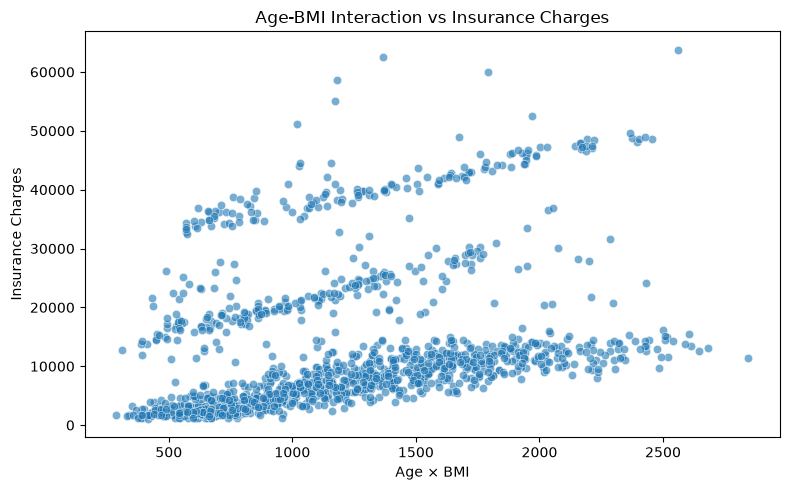

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age_bmi_interaction",
    y="charges",
    alpha=0.6
)

plt.title("Age-BMI Interaction vs Insurance Charges")
plt.xlabel("Age × BMI")
plt.ylabel("Insurance Charges")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member4_age_bmi_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
correlations = df[
    [
        "age",
        "bmi",
        "age_bmi_interaction",
        "charges"
    ]
].corr()

display(correlations)

print("\nCorrelation with Charges:")

display(
    correlations["charges"]
    .sort_values(ascending=False)
)

,age,bmi,age_bmi_interaction,charges
age,1.000000,0.109272,0.879840,0.299008
bmi,0.109272,1.000000,0.539637,0.198341
age_bmi_interaction,0.879840,0.539637,1.000000,0.334754
charges,0.299008,0.198341,0.334754,1.000000



Correlation with Charges:


charges                1.000000
age_bmi_interaction    0.334754
age                    0.299008
bmi                    0.198341
Name: charges, dtype: float64

## EDA Interpretation

The scatter plot visualizes the relationship between the newly created
Age-BMI interaction feature and insurance charges.

The new feature represents the combined effect of age and BMI rather than
considering each variable independently.

The correlation analysis can be used to compare its linear relationship with
charges against the original age and BMI variables.

However, the creation of a feature does not guarantee better predictions.
Its actual usefulness should be evaluated during model development.

In [7]:
df.to_csv(
    "../results/outputs/member4_feature_engineered.csv",
    index=False
)

print("Member 4 preprocessing completed.")

Member 4 preprocessing completed.
